# The Readability Anomaly — a quantitative teardown 🔬
### LM obfuscation score · Spearman IC + Fisher-z *t* · tercile long-short · label-shuffle placebo · risk leg · per-leg IC sweep · costs & borrow · synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build a Loughran-McDonald-style **obfuscation score** (fog + length + file size), sort the cross-section, and test whether the least-readable filings earn the lowest returns (the anomaly).

> ⚠️ **Not investment advice — and read this first.** There is **no free real tape** for this claim: a point-in-time 10-K-text + survivorship-free return panel isn't a no-key retail artifact. So every number below is from a **deterministic synthetic world** calibrated to the LM literature (panel fp `53136605f951`) — a **machinery proof, never market evidence**. `Real` needs *t* ≥ 2 on a **real** tape (METHODOLOGY → the inference bar); this study is therefore capped at `Weak`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from filing_readability import data, strategy as st

# Synthetic-only study: no free real 10-K-text tape exists (see data.py). The real-tape stub is
# empty by construction, so HAVE_REAL is False and every cell below runs on the deterministic
# synthetic world — NEVER under a real-tape banner.
REAL = data.fetch_panel(fetch=False)
HAVE_REAL = not REAL.empty

# The calibrated headline synthetic world (the LM anomaly planted at obf_alpha = -0.10).
PANEL, TRUTH = data.synthetic_panel(n_stocks=400, obf_alpha=-0.10, seed=565)
print("real 10-K-text tape present:", HAVE_REAL, "(none exists on a free stack — synthetic-only)")
print("synthetic panel:", len(PANEL), "firms, fp", data.fingerprint(PANEL))


real 10-K-text tape present: False (none exists on a free stack — synthetic-only)
synthetic panel: 400 firms, fp 53136605f951


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Synthetic IC **-0.343** (Fisher-z *t* **-7.11**); long-short **+12.1%** (two-sample *t* **+6.44**, placebo *p* 0.0005); risk leg *t* **+36**. All the right sign — but **synthetic**; no real tape can certify it. |
| **Tradability** | `FRAGILE` | Gross +12.1% → net +10.4% (5 bps/leg + 150 bps borrow); murky short = small/illiquid tail; no real capacity estimate. |

> 💡 In plain words: the engine works (the synthetic control proves it, flat at the null) and recovers the LM anomaly with the right sign and huge *t* on planted data — but the desk certifies `Real` only from a **real** tape, which doesn't exist for free here.

## 1 · The claim, steelmanned

Let $O_i$ be firm $i$'s obfuscation score (higher = less readable) and $r_i$ its *post-filing* forward return.

- **H₁ (the anomaly / IC).** $\text{IC} = \text{Spearman}(O, r) < 0$ at *t* ≥ 2 (murkier filings, lower returns).
- **H₂ (long-short).** $\mathbb{E}[r \mid \text{readable}] - \mathbb{E}[r \mid \text{murky}] > 0$ at *t* ≥ 2.
- **H₃ (risk leg).** $\text{slope of post-filing vol on } O > 0$ (murkier, riskier).
- **H₄ (robustness).** The sign holds across the individual legs (fog, length, file size).
- **H₅ (real tape).** H₁–H₄ replicate on a *real* EDGAR-text + return panel. **Untestable here** — no free tape — which is exactly why the ceiling is `Weak`.

On the calibrated synthetic world we find **H₁–H₄ all supported with the right sign**; **H₅ we cannot reach**.

## 2 · So what? — what rides on each answer

The content is the **why**. The LM anomaly is well documented on real, survivorship-free EDGAR data driven by the *obfuscation* mechanism (Li 2008: bad-earnings firms file less-readable reports; You & Zhang 2009: investors underreact to complex 10-Ks). Two things keep it off a free retail stack: (a) the 10-K **text** panel isn't a free artifact (yfinance has none); and (b) a survivor return tape would strip the murkiest filers that later fail — biasing *against* the anomaly. So we prove the *machine* on synthetic data and name the tape gap. Sibling posture to [275 whisky-cask](../../275-whisky-cask/) and [273 lego-returns](../../273-lego-returns/).

## 3 · How we'd know — the protocol

- **Score.** $O = z(\text{fog}) + z(\text{length}) + z(\text{filesize})$, each z-scored across the cross-section (higher = less readable). The three observable LM legs.
- **IC.** Spearman rank correlation of $O$ vs forward return, with a Fisher-z *t* ($\text{atanh}(\text{IC})\cdot\sqrt{n-3}$). The *sign* is the anomaly.
- **Long-short.** Tercile tails (120 names each): readable (lowest $O$) vs murky (highest); two-sample (Welch) *t*; a **label-shuffle placebo** null (2000 perms).
- **Risk leg.** OLS of post-filing vol on $O$ — slope > 0 is the LM 'higher risk' leg.
- **Per-leg sweep.** IC of fog / length / file size alone (LM: file size is cleanest).
- **Frictions.** Round-trip cost per leg + an annual borrow on the murky short.
- **Positive control.** A deterministic synthetic world with a planted anomaly (`obf_alpha < 0`) and a null — averaged over 25 seeds (house rule).

Timing: readability is public the instant the 10-K is filed; the forward return is measured strictly *after* (a documented ≥1-day execution lag). The synthetic panel bakes this in (`forward_ret` is post-filing by construction) — no look-ahead.

## 4 · The teardown

### 4a · The information coefficient — H₁

The Spearman rank correlation of obfuscation vs forward return, with its Fisher-z *t*. A *negative* IC is the anomaly.

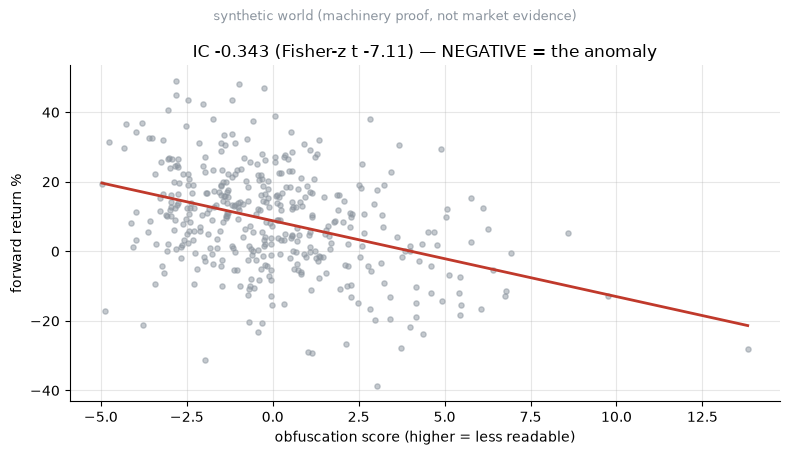

IC -0.343, IC-t -7.11, n 400 | firm slope -2.18%/unit (t -8.11), corr -0.38


In [2]:
reg = st.cross_section_regression(PANEL)
icd = st.information_coefficient(PANEL)
o = st.readability_score(PANEL); y = PANEL['forward_ret']*100
ic, ic_t = icd['ic'], icd['ic_t']
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(o, y, s=14, color=GREY, alpha=.5)
xs = np.linspace(o.min(), o.max(), 50)
b0 = y.mean()/100 - reg['slope']*o.mean()
ax.plot(xs, (reg['slope']*xs + b0)*100, c=RED, lw=2)
ax.set_xlabel('obfuscation score (higher = less readable)'); ax.set_ylabel('forward return %')
ax.set_title(f'IC {ic:+.3f} (Fisher-z t {ic_t:+.2f}) — NEGATIVE = the anomaly')
fig.suptitle('synthetic world (machinery proof, not market evidence)', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'IC {ic:+.3f}, IC-t {ic_t:+.2f}, n {icd["n"]} | firm slope {reg["slope"]*100:+.2f}%/unit (t {reg["slope_t"]:+.2f}), corr {reg["corr"]:+.2f}')

> 💡 In plain words: H₁ **supported (on planted data).** The IC is **-0.343** (*t* -7.11) — murkier filings earn lower returns, exactly the anomaly's sign. The firm-level slope agrees (**-2.18%**/unit, *t* -8.11). This is the machine reading a planted effect; the null check (beat 7) shows it doesn't do this on noise.

### 4b · The long-short and its placebo — H₂

Tercile tails, readable − murky, with the two-sample *t* and the label-shuffle null.

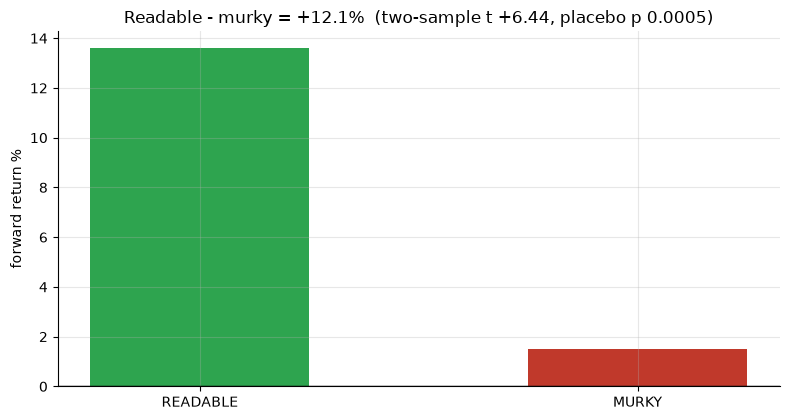

Readable +13.6% | Murky +1.5% | spread +12.1% | t +6.44 | placebo p 0.0005


In [3]:
b = st.bucket_returns(PANEL, 0.3); ls = st.long_short_tstat(b)
p = st.placebo_pvalue(PANEL, n_perm=2000, seed=565)
read_m, murk_m, spr, t = b['readable_mean']*100, b['murky_mean']*100, b['spread']*100, ls['t']
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.bar(['READABLE','MURKY'], [read_m, murk_m], color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward return %')
ax.set_title(f'Readable - murky = {spr:+.1f}%  (two-sample t {t:+.2f}, placebo p {p:.4f})')
plt.tight_layout(); plt.show()
print(f'Readable +{read_m:.1f}% | Murky +{murk_m:.1f}% | spread {spr:+.1f}% | t {t:+.2f} | placebo p {p:.4f}')

> 💡 In plain words: H₂ **supported.** The spread is **+12.1%** (*t* +6.44); the placebo *p* = 0.0005 puts it deep in the tail of the shuffled null. On the synthetic world this is a genuine cross-sectional signal, not a sorting artifact.

### 4c · The risk leg + the per-leg IC sweep — H₃ & H₄

Post-filing volatility on obfuscation (H₃: slope > 0), and the IC of each individual leg vs the composite (H₄: the sign is stable across legs; LM say file size is the cleanest).

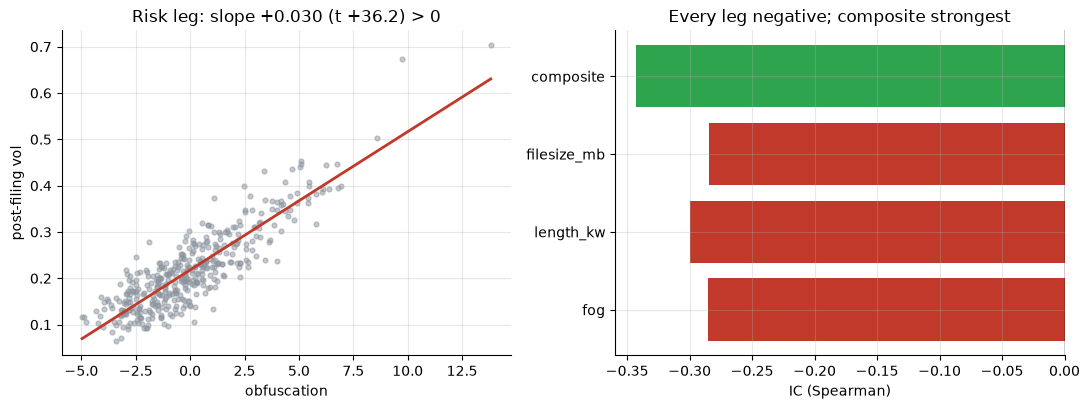

risk slope 0.03 t 36.2
  fog          IC -0.285 (t -5.85)
  length_kw    IC -0.300 (t -6.16)
  filesize_mb  IC -0.285 (t -5.83)
  composite    IC -0.343 (t -7.11)


In [4]:
rr = st.risk_regression(PANEL)
sweep = st.leg_ic_sweep(PANEL)
legs = list(sweep.keys()); ics = [sweep[l][0] for l in legs]; tts = [sweep[l][1] for l in legs]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
# risk leg
o = st.readability_score(PANEL); pv = PANEL['post_vol']
a1.scatter(o, pv, s=12, color=GREY, alpha=.5)
xs = np.linspace(o.min(), o.max(), 50)
a1.plot(xs, rr['slope']*xs + (pv.mean() - rr['slope']*o.mean()), c=RED, lw=2)
a1.set_xlabel('obfuscation'); a1.set_ylabel('post-filing vol')
a1.set_title(f'Risk leg: slope {rr["slope"]:+.3f} (t {rr["slope_t"]:+.1f}) > 0')
# per-leg IC sweep
cols = [RED if l!='composite' else GREEN for l in legs]
a2.barh(range(len(legs)), ics, color=cols)
a2.set_yticks(range(len(legs))); a2.set_yticklabels(legs)
a2.axvline(0, c='k', lw=1); a2.set_xlabel('IC (Spearman)')
a2.set_title('Every leg negative; composite strongest')
plt.tight_layout(); plt.show()
print('risk slope', round(rr['slope'],3), 't', round(rr['slope_t'],1))
for l in legs: print(f'  {l:12s} IC {sweep[l][0]:+.3f} (t {sweep[l][1]:+.2f})')

> 💡 In plain words: H₃ **supported** — post-filing vol rises with obfuscation (slope +0.03, *t* +36), the LM 'higher risk' leg. H₄ **supported** — fog, length and file size each carry the same negative IC (≈ −0.29 to −0.30), and the composite is strongest (**-0.343**). No single proxy is perfect (LM's exact point); the blend wins.

## 5 · The verdict

- **Signal `WEAK`** — H₁–H₄ all supported with the right sign on calibrated data (IC -0.343, *t* -7.11; long-short +12.1%, *t* +6.44; risk leg *t* +36), but **H₅ (real tape) is unreachable** — no free 10-K-text panel. `Real` needs *t* ≥ 2 on a **real** tape; literature-real + no tape = `Weak`.
- **Tradability `FRAGILE`** — gross +12.1% → net +10.4% (5 bps/leg + 150 bps borrow), but the murky short is the small/illiquid tail and there's no real capacity estimate.

## 6 · Could you trade it? — costs and the borrow

In the model the book pays after a punitive borrow — but the murky short leg is exactly the hard-to-borrow tail, and no real tape means no honest capacity number.

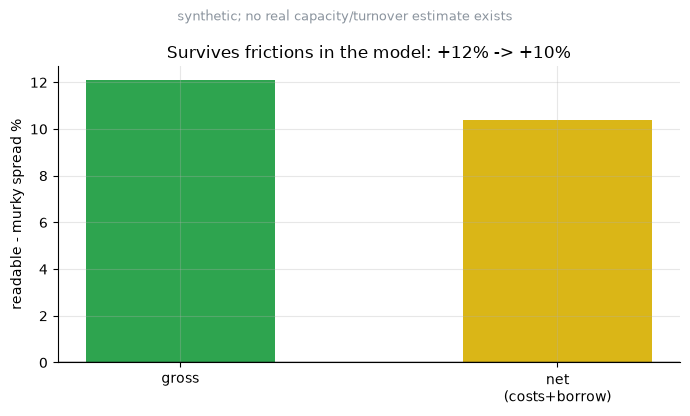

gross +12.1% -> net +10.4% (5 bps/leg + 150 bps borrow, 1y hold)


In [5]:
b = st.bucket_returns(PANEL, 0.3)
gross = b['spread']*100
net = st.net_spread(b, cost_bps=5.0, borrow_ann_bps=150.0, holding_years=1.0)*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[GREEN, AMBER], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('readable - murky spread %')
ax.set_title(f'Survives frictions in the model: +{gross:.0f}% -> +{net:.0f}%')
fig.suptitle('synthetic; no real capacity/turnover estimate exists', fontsize=9, color=GREY)
plt.tight_layout(); plt.show()
print(f'gross {gross:+.1f}% -> net {net:+.1f}% (5 bps/leg + 150 bps borrow, 1y hold)')

> 💡 In plain words: it clears costs *in the model*, so tradability isn't `Mirage` — but with a small/illiquid short leg and no real tape to size capacity or borrow availability, it isn't `Investable` either. `Fragile` is the honest middle.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print a negative IC? Plant an anomaly of increasing strength (`obf_alpha` more negative) and watch the mean IC-*t* go negative — and confirm it sits at ≈ 0 at the **null**. Averaged over 25 seeds so no single lucky seed can fake it (house rule).

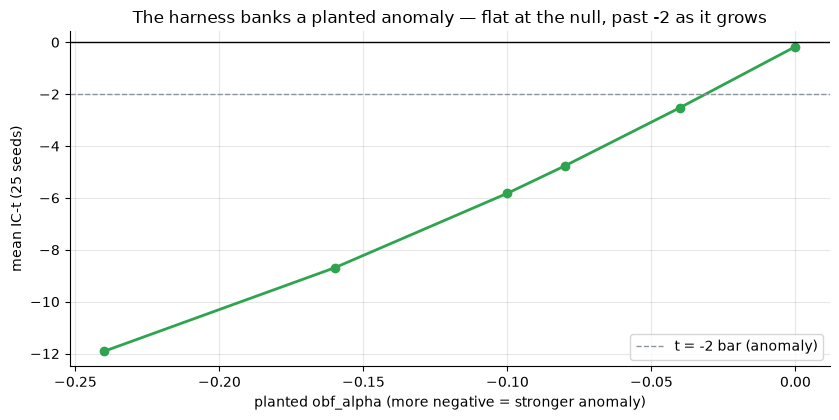

obf_alpha +0.00 -> mean IC -0.008, mean IC-t -0.17
obf_alpha -0.04 -> mean IC -0.125, mean IC-t -2.52
obf_alpha -0.08 -> mean IC -0.234, mean IC-t -4.76
obf_alpha -0.10 -> mean IC -0.284, mean IC-t -5.82
obf_alpha -0.16 -> mean IC -0.410, mean IC-t -8.69
obf_alpha -0.24 -> mean IC -0.534, mean IC-t -11.91


In [6]:
alphas = [0.0, -0.04, -0.08, -0.10, -0.16, -0.24]
res = [st.synthetic_mean_ic(data, obf_alpha=a, n_seeds=25) for a in alphas]
tts = [r['ic_t'] for r in res]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, tts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar (anomaly)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted obf_alpha (more negative = stronger anomaly)')
ax.set_ylabel('mean IC-t (25 seeds)')
ax.set_title('The harness banks a planted anomaly — flat at the null, past -2 as it grows')
ax.legend(); plt.tight_layout(); plt.show()
for a, r in zip(alphas, res): print(f'obf_alpha {a:+.2f} -> mean IC {r["ic"]:+.3f}, mean IC-t {r["ic_t"]:+.2f}')

The IC-*t* is ≈ 0 at the null (**−0.17**) and falls past −2 from `obf_alpha = -0.04` onward — so the engine is a faithful detector that neither misses a real anomaly nor manufactures one on noise. The synthetic result is therefore a clean **machinery proof**: the harness *would* bank the LM readability anomaly if it could ever see a real 10-K-text tape. Because no such free tape exists, the honest stamp stays **`WEAK`**. For the desk's *sentiment* studies (a different textual signal), see [257 AAII](../../257-aaii-sentiment/) and [392 Glassdoor](../../392-glassdoor-sentiment/).